In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay

In [2]:
diabetes_data = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/diabetes 2.csv')

In [3]:
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,7,127.978658,74.434931,30.795284,57.937568,29.524220,0.458167,41,1
1,9,100.178783,60.909403,26.770289,112.454493,34.355269,0.365299,30,1
2,1,90.264591,61.673580,31.801643,96.688063,26.567985,0.427536,37,1
3,1,161.083229,92.460974,33.223057,190.645597,28.910178,0.721804,64,0
4,4,139.601992,64.428156,39.060670,63.480335,28.796877,0.403001,35,0


In [4]:
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,964.000000,964.000000,964.000000,964.000000,964.000000,964.000000,964.000000,964.000000,964.00000
mean,6.858921,121.264163,70.600467,25.106220,81.767095,29.886359,0.522150,43.303942,0.50000
std,4.344081,31.493230,12.070403,7.784677,38.162614,5.874254,0.277563,14.806889,0.50026
min,0.000000,50.000000,40.000000,10.000000,15.000000,15.000000,0.100000,18.000000,0.00000
25%,3.000000,101.166108,62.285977,19.691100,55.329655,25.826711,0.307019,31.000000,0.00000
50%,7.000000,121.908765,70.960602,24.998921,80.048890,30.117524,0.511531,43.000000,0.50000
75%,11.000000,142.864532,78.842939,30.352099,108.238207,33.908275,0.717463,56.000000,1.00000
max,14.000000,200.000000,100.000000,50.000000,226.308072,47.045318,1.579840,69.000000,1.00000


In [5]:
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 964 entries, 0 to 963
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               964 non-null    int64  
 1   Glucose                   964 non-null    float64
 2   BloodPressure             964 non-null    float64
 3   SkinThickness             964 non-null    float64
 4   Insulin                   964 non-null    float64
 5   BMI                       964 non-null    float64
 6   DiabetesPedigreeFunction  964 non-null    float64
 7   Age                       964 non-null    int64  
 8   Outcome                   964 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 67.9 KB


In [6]:
diabetes_data.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
diabetes_data.value_counts

<bound method DataFrame.value_counts of      Pregnancies     Glucose  ...  Age  Outcome
0              7  127.978658  ...   41        1
1              9  100.178783  ...   30        1
2              1   90.264591  ...   37        1
3              1  161.083229  ...   64        0
4              4  139.601992  ...   35        0
..           ...         ...  ...  ...      ...
959            8   96.091457  ...   45        0
960            2  142.262538  ...   61        0
961            1  113.249823  ...   52        0
962           13  112.940438  ...   60        1
963            9  161.533263  ...   63        1

[964 rows x 9 columns]>

In [8]:
diabetes_data.shape

(964, 9)

In [9]:
X = diabetes_data.drop('Outcome', axis=1)
y = diabetes_data['Outcome']

Train a simple model: 

In [10]:
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

RandomForestRegressor(random_state=42)

In [13]:
featues = diabetes_data[["BMI","Glucose"]]

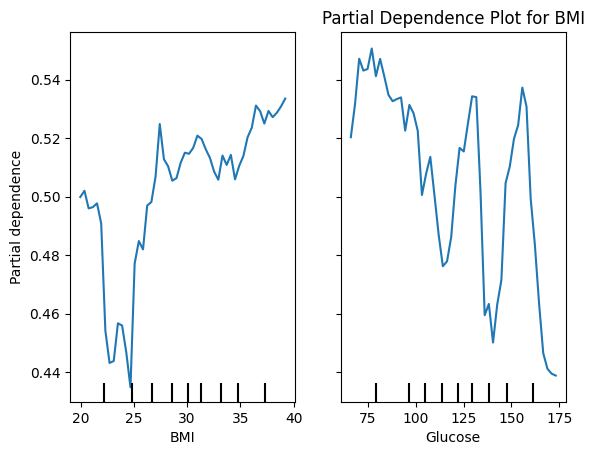

In [17]:
#Partial Dependence Plot for BMI:
PartialDependenceDisplay.from_estimator(model,X, featues, 
                                        kind="average",
                                        grid_resolution=50)
plt.title("Partial Dependence Plot for BMI")
plt.show()